# PVT sweep — 8T DCIM bitcell

This notebook runs a PVT (Process, Voltage, Temperature) sweep for the 8T DCIM bitcell design in this repository. 
- Automates running transistor-level simulations across combinations of process corners, supply voltages and temperatures
- Collects key metrics (delay, power, timing, margin etc.) 
- Visualizes the results to help characterize robustness and yield.

## Step 0 -- Configure Workspace PATHS

In [1]:
from pathlib import Path

# -- paths: HOST_* (on your machine, via `nix develop`)
HOST_WORKSPACE = Path.cwd().parent.parent.resolve()
TARGET_DIR = HOST_WORKSPACE / "analog" / "flow"

ROOT    = HOST_WORKSPACE / "analog"
PVT     = ROOT / "designs" / "pvt.spice"
SIM8T   = ROOT / "sim" / "8t"
RESULTS = ROOT / "flow" / "results"
RESULTS.mkdir(parents=True, exist_ok=True)

# -- paths: CONTAINER_* (inside IIC-OSIC-TOOLS, where ngspice + the GF180 PDK live)
# The decks under sim/8t/ and designs/pvt.spice hardcode ".include /workspace/analog/..."
# -- do not change CONTAINER_WORKSPACE without also rewriting those .spice files.
CONTAINER_WORKSPACE = "/workspace/analog"
GF180 = "/foss/pdks/gf180mcuD/libs.tech/ngspice"

# -- corners: name, GF180 lib corner, temp (C), VDD (V)
# lib must match a .LIB section in sm141064.ngspice: typical, ff, ss, fs, sf (no "tt")
CORNERS = [
    dict(name="TT_25_3p3",   lib="typical", temp=25,  vdd=3.30),  # typical corner
    dict(name="SS_125_2p97", lib="ss",      temp=125, vdd=2.97),  # extreme hot-slow
    dict(name="FF_m40_3p63", lib="ff",      temp=-40, vdd=3.63),  # extreme cold-fast
    dict(name="SS_m40_2p97", lib="ss",      temp=-40, vdd=2.97),  # extreme cold-slow
    dict(name="FF_125_3p63", lib="ff",      temp=125, vdd=3.63),  # extreme hot-fast
    dict(name="SF_125_2p97", lib="sf",      temp=125, vdd=2.97),  # strong-P/weak-N: skews latch balance
    dict(name="FS_125_2p97", lib="fs",      temp=125, vdd=2.97),  # weak-P/strong-N: opposite skew
]

# test name -> deck file (all under sim/8t/)
TESTS = ["hold_run", "write_run", "write_margin", "hold_snm",
         "mult_w0a0_test", "mult_w0a1_test", "mult_w1a0_test",
         "mult_w1a1_test", "compute_disturb_hi", "compute_disturb_lo", "read_run"]

print(f"TARGET_DIR: {TARGET_DIR}")
print(f"RESULTS:    {RESULTS}")

TARGET_DIR: /home/ratishgupta/vlsi/blueprints/analog/flow
RESULTS:    /home/ratishgupta/vlsi/blueprints/analog/flow/results


## Step 1a -- Start the IIC-OSIC-TOOLS container

ngspice and the GF180 PDK only exist inside the IIC-OSIC-TOOLS container (not in the `nix develop` shell this notebook runs in). This cell runs `scripts/run_docker_iic.sh` with `IIC_DETACH=1` (so it starts in the background, `-d`, instead of the default interactive `-it`) if the container isn't already up.

`run_docker_iic.sh` bind-mounts this whole repo at `/workspace`, so `/workspace/analog` will already be live and in sync with the host once the container starts -- nothing needs to be copied in.

In [2]:
import os
import subprocess

CONTAINER_NAME = "chipathon-2026-iic"  # fixed by scripts/run_docker_iic.sh --name
LAUNCH_SCRIPT = HOST_WORKSPACE / "scripts" / "run_docker_iic.sh"

already_up = subprocess.run(
    ["docker", "ps", "-q", "--filter", f"name=^{CONTAINER_NAME}$"],
    capture_output=True, text=True, check=True,
).stdout.strip()

if not already_up:
    # -d returns as soon as the container starts (unlike -it), so this is a plain
    # synchronous call -- no backgrounding/polling needed.
    subprocess.run(["bash", str(LAUNCH_SCRIPT)], env={**os.environ, "IIC_DETACH": "1"}, check=True)

print(f"CONTAINER: {CONTAINER_NAME}")

CONTAINER: chipathon-2026-iic


## Step 1b -- Verify ngspice and the /workspace mount

In [3]:
def docker_exec(*args, cwd=None, **kwargs):
    """docker exec via a login shell (bash -lc) -- ngspice etc. only land on PATH
    through the container's profile scripts, not the bare docker-exec PATH."""
    docker_args = ["docker", "exec"]
    if cwd:
        docker_args += ["-w", cwd]
    docker_args += [CONTAINER_NAME, "bash", "-lc", " ".join(args)]
    return subprocess.run(docker_args, **kwargs)


check = docker_exec("command", "-v", "ngspice", capture_output=True, text=True)
# the profile prints its own "[INFO] Final PATH variable: ..." noise to stdout first
ngspice_path = next((l for l in reversed(check.stdout.splitlines()) if l.strip()), "")
if check.returncode != 0 or not ngspice_path.startswith("/"):
    raise RuntimeError(f"ngspice not found in container '{CONTAINER_NAME}': {check.stderr.strip()}")
print(f"ngspice:   {ngspice_path}")

mount_check = docker_exec("test", "-f", f"{CONTAINER_WORKSPACE}/designs/pvt.spice")
if mount_check.returncode != 0:
    raise RuntimeError(
        f"{CONTAINER_WORKSPACE}/designs/pvt.spice not visible in container '{CONTAINER_NAME}' "
        "-- is the repo mounted at /workspace?"
    )
print(f"mount OK:  {CONTAINER_WORKSPACE} (live bind mount of {HOST_WORKSPACE})")

ngspice:   /foss/tools/bin/ngspice
[INFO] Final PATH variable: /foss/tools/bin:/foss/tools/sak:/usr/local/sbin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/foss/tools/kactus2:/foss/tools/klayout:/foss/tools/osic-multitool
[INFO] Final PYTHONPATH variable: /usr/lib/python312.zip:/usr/lib/python3.12:/usr/lib/python3.12/lib-dynload:/usr/local/lib/python3.12/dist-packages:/usr/lib/python3/dist-packages:/foss/tools/ngspyce/local/lib/python3.12/dist-packages:/foss/tools/openems/local/lib/python3.12/dist-packages:/foss/tools/pyopus/local/lib/python3.12/dist-packages:/foss/tools/yosys/share/yosys/python3:/foss/tools/klayout/pymod:/foss/tools/vacask/lib/vacask/python
mount OK:  /workspace/analog (live bind mount of /home/ratishgupta/vlsi/blueprints)


## Step 2 -- Helper functions

`write_pvt()` is the only file this notebook writes -- written on the host, live-visible to the container via the `/workspace` mount, so no push step is needed. `run_ngspice()` runs a deck inside the container. `had_error`/`meas_last`/`meas_all` are pure text parsing over ngspice's stdout, unchanged from the pre-Docker version of this notebook.

In [4]:
import re

NUM = r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?"

# --- pvt.spice template: the ONLY file rewritten per corner ---
PVT_TEMPLATE = """* File: pvt.spice
* AUTO-GENERATED by pvt_sweep.ipynb -- corner: {name}  (do not hand-edit during a sweep)
.include {gf180}/design.ngspice
.lib {gf180}/sm141064.ngspice {lib}
.temp {temp}
.param VDD_CORNER={vdd}
"""


def write_pvt(corner):
    """Regenerate designs/pvt.spice for one corner."""
    PVT.write_text(PVT_TEMPLATE.format(gf180=GF180, **corner))


def to_container_path(path):
    """Host path under ROOT -> the equivalent path inside the container."""
    return f"{CONTAINER_WORKSPACE}/{path.relative_to(ROOT).as_posix()}"


def run_ngspice(deck):
    """Headless batch run of one deck inside the container; stdout+stderr captured."""
    return docker_exec("ngspice", "-b", to_container_path(deck), cwd=CONTAINER_WORKSPACE,
                        capture_output=True, text=True, timeout=300)


def had_error(proc):
    """ngspice -b often exits 0 even on a bad deck -- also scan output."""
    blob = proc.stdout + proc.stderr
    return proc.returncode != 0 or re.search(
        r"(?im)^\s*(fatal|undefined parameter|can't find|error on line|syntax error)", blob
    ) is not None

def meas_last(out, name):
    """Last 'name = value' (ngspice meas / print) as float, or None."""
    m = re.findall(rf"^\s*{re.escape(name)}\s*=\s*({NUM})", out, re.M)
    return float(m[-1]) if m else None


def meas_all(out, name):
    """All 'name = value' in order -- for multi-tran decks (and_multiply)."""
    return [float(x) for x in re.findall(rf"^\s*{re.escape(name)}\s*=\s*({NUM})", out, re.M)]

## Step 3 -- Signoff specs and evaluate()

`SPECS` is the table-driven source of truth for pass/fail bands. `hold_snm`, `write_margin`, and `and_multiply` map directly onto their like-named decks. `hold_retain` is shared by `read_disturb_hi` and `read_disturb_lo` -- both check that `Q` survives repeated reads, mirrored around the corner `vdd` (hi: `q_final >= 0.9*vdd`, lo: `q_final <= 0.1*vdd`, using the same `limit(vdd)` so the 0.1 isn't a second hardcoded number). `hold_run`, `write_run`, and `read_run` aren't in `SPECS` and keep their original hardcoded thresholds. `read_snm` has no corresponding deck yet, so it's unused for now.

In [5]:
import operator

SPECS = {
    "hold_snm":     {"metric": "snm",      "op": ">=", "limit": lambda v: 0.755, "unit": "V", "interim": False},
    "read_snm":     {"metric": "snm",      "op": ">=", "limit": lambda v: v/6,   "unit": "V", "interim": True},
    "write_margin": {"metric": "wlwm",     "op": ">",  "limit": lambda v: 0.912, "unit": "V", "interim": False},
    "hold_retain":  {"metric": "q_final",  "op": ">=", "limit": lambda v: 0.9*v, "unit": "V", "interim": False},
    "and_multiply": {"metric": "rbl_delta","op": ">=", "limit": lambda v: v/2,   "unit": "V", "interim": True},
}


OPS = {">=": operator.ge, ">": operator.gt, "<=": operator.le, "<": operator.lt}


def spec_pass(spec_key, value, vdd):
    """Apply SPECS[spec_key]'s pass/fail band to a measured value."""
    if value is None:
        return False
    spec = SPECS[spec_key]
    return OPS[spec["op"]](value, spec["limit"](vdd))


def evaluate(test, out, vdd):
    """Extract metrics for one deck's stdout. Returns list of {metric, value, pass}."""
    rows = []
    def add(metric, value, ok):
        rows.append({"metric": metric, "value": value, "pass": bool(ok)})

    if test == "hold_run":               # idle hold -- not in SPECS, original literal bands
        q, qb = meas_last(out, "q_final"), meas_last(out, "qb_final")
        add("q_final",  q,  q  is not None and q  >= 0.9 * vdd)
        add("qb_final", qb, qb is not None and qb <= 0.1 * vdd)

    elif test == "write_run":            # writes Q: 1 -> 0 -- not in SPECS
        q = meas_last(out, "q_final")
        add("q_final", q, q is not None and q <= 0.1 * vdd)

    elif test == "write_margin":         # ngspice computes the margin
        m = re.search(rf"WLWM_RESULT\s*:\s*({NUM})", out)
        margin = float(m.group(1)) if m else None
        endpoints_ok = "[FAIL]" not in out
        add("wlwm", margin, endpoints_ok and spec_pass("write_margin", margin, vdd))

    elif test == "hold_snm":              # ngspice computes the SNM
        snm = meas_last(out, "hold_snm")
        add("snm", snm, spec_pass("hold_snm", snm, vdd))

    elif test == "and_multiply":         # 4 cases: (0,0)(1,0)(0,1)(1,1); AND=1 is LAST
        mult = meas_all(out, "mult_final")
        if len(mult) == 4:
            # active-low RBL: the AND=1 case (mult[3]) must be the most discharged.
            if mult[3] != min(mult):
                print(f"[!] and_multiply: AND=1 case not the minimum {mult} "
                      f"-- compute port may have failed this corner")
            delta = min(mult[:3]) - mult[3]
        else:
            delta = None
        add("rbl_delta", delta, spec_pass("and_multiply", delta, vdd))

    elif test == "read_disturb_hi":      # Q=1 must survive repeated reads
        q = meas_last(out, "q_final")
        add("q_final", q, spec_pass("hold_retain", q, vdd))

    elif test == "read_disturb_lo":      # Q=0 must survive repeated reads -- mirror of hold_retain
        q = meas_last(out, "q_final")
        limit = SPECS["hold_retain"]["limit"](vdd)     # 0.9*vdd
        add("q_final", q, q is not None and q <= vdd - limit)   # 0.1*vdd

    elif test == "read_run":             # non-destructive write-port read (this deck: Q=0) -- not in SPECS
        q, qb = meas_last(out, "q_final"), meas_last(out, "qb_final")
        add("q_final",  q,  q  is not None and q  <= 0.1 * vdd)
        add("qb_final", qb, qb is not None and qb >= 0.9 * vdd)

    return rows

## Step 4 -- The sweep

Loops `CORNERS x TESTS` (5 x 8 = 40 ngspice runs via `docker exec`), regenerating `designs/pvt.spice` per corner and evaluating each deck's stdout. The original `pvt.spice` is restored in `finally` so git stays clean even if a run raises or the container drops mid-sweep.

In [6]:
import pandas as pd

# --- the sweep ---
records = []
original_pvt = PVT.read_text()   # restore at the end so git stays clean
try:
    for corner in CORNERS:
        write_pvt(corner)
        for test in TESTS:
            proc = run_ngspice(SIM8T / f"{test}.spice")
            err  = had_error(proc)
            if err:
                print(f"[!] {corner['name']:<13} {test:<16} ngspice flagged an error "
                      f"(rc={proc.returncode}) -- inspect proc output")
            for row in evaluate(test, proc.stdout, corner["vdd"]):
                records.append(dict(corner=corner["name"], lib=corner["lib"],
                                    temp=corner["temp"], vdd=corner["vdd"],
                                    test=test, ran_ok=not err, **row))
finally:
    PVT.write_text(original_pvt)         # always restore, even on exception

df = pd.DataFrame(records)
df.to_csv(RESULTS / "pvt_sweep.csv", index=False)
print(f"{len(df)} rows -> {RESULTS/'pvt_sweep.csv'}")
df

49 rows -> /home/ratishgupta/vlsi/blueprints/analog/flow/results/pvt_sweep.csv


,corner,lib,temp,vdd,test,ran_ok,metric,value,pass
0,TT_25_3p3,typical,25,3.30,hold_run,True,q_final,3.300000e+00,True
1,TT_25_3p3,typical,25,3.30,hold_run,True,qb_final,1.022240e-08,True
2,TT_25_3p3,typical,25,3.30,write_run,True,q_final,1.043550e-08,True
3,TT_25_3p3,typical,25,3.30,write_margin,True,wlwm,1.385740e+00,True
4,TT_25_3p3,typical,25,3.30,hold_snm,True,snm,9.880443e-01,True
5,TT_25_3p3,typical,25,3.30,read_run,True,q_final,1.092020e-08,True
6,TT_25_3p3,typical,25,3.30,read_run,True,qb_final,3.300000e+00,True
7,SS_125_2p97,ss,125,2.97,hold_run,True,q_final,2.970000e+00,True
8,SS_125_2p97,ss,125,2.97,hold_run,True,qb_final,1.984410e-08,True
9,SS_125_2p97,ss,125,2.97,write_run,True,q_final,2.201900e-08,True


## Step 5 -- Worst-case report

In [7]:
fails = df[~df["pass"]]
print(f"{len(fails)} FAIL row(s)" if len(fails) else "All metrics PASS across all corners.")
if len(fails):
    display(fails[["corner", "test", "metric", "value", "ran_ok"]])

# value of every metric vs corner (quick scan)
df.pivot_table(index=["test", "metric"], columns="corner", values="value", aggfunc="first")

interim = [k for k, s in SPECS.items() if s.get("interim")]
print(f"\n[INTERIM THRESHOLDS] {', '.join(interim)} use textbook floors (VDD/6, VDD/2), "
      f"not yield-derived. Replace with μ−4.6σ after Monte Carlo before treating as signoff.")

All metrics PASS across all corners.

[INTERIM THRESHOLDS] read_snm, and_multiply use textbook floors (VDD/6, VDD/2), not yield-derived. Replace with μ−4.6σ after Monte Carlo before treating as signoff.


## Step 6 -- Margin plots

Metric names here (`snm`, `wlwm`) come from `evaluate()`/`SPECS` in Step 3 -- not the `hold_snm`/`WLWM_margin` names used in the pre-Docker version of this notebook.

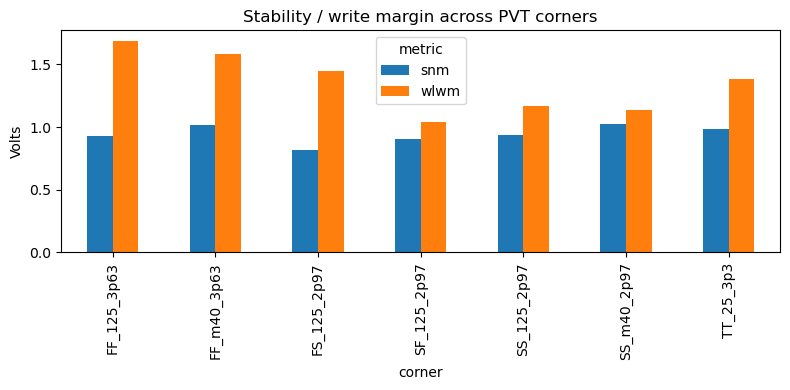

In [8]:
import matplotlib.pyplot as plt

margins = df[df["metric"].isin(["snm", "wlwm"])]
piv = margins.pivot_table(index="corner", columns="metric", values="value")
ax = piv.plot.bar(figsize=(8, 4))
ax.set_ylabel("Volts"); ax.set_title("Stability / write margin across PVT corners")
ax.axhline(0, color="k", lw=0.6)
plt.tight_layout(); plt.savefig(RESULTS / "margins.png", dpi=120); plt.show()